<a href="https://colab.research.google.com/github/matheuscbrito/perceptron-trilha/blob/main/Matheus_Brito_perceptron_e_decision_tree_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Perceptron com NumPy + 🌲 Árvore de Decisão no Titanic

Neste notebook você vai:

1. **Implementar um Perceptron do zero** usando apenas `numpy` (sem `scikit-learn` para o modelo).
2. **(Desafio opcional)** Analisar o dataset **Titanic** e treinar um modelo de **Árvore de Decisão** (`DecisionTreeClassifier`).

> 💡 Complete os trechos marcados com `# TODO:` e execute as células na ordem. Mãos à obra!

# Parte 1 — Perceptron do zero com NumPy

## 🧩 O que é o Perceptron?

O Perceptron é um **classificador linear binário**. Para uma entrada $x$ (vetor de características), ele calcula uma combinação linear:

$$z = w \cdot x + b = \sum_{i} w_i\, x_i + b$$

e aplica uma **função degrau** para decidir a classe:

$$\hat{y} = \begin{cases} 1, & \text{se } z \ge 0 \\ 0, & \text{caso contrário} \end{cases}$$

**Regra de aprendizado:** para cada amostra, se houver erro $e = y - \hat{y}$, atualizamos:

$$w \leftarrow w + \eta\, e\, x$$

$$b \leftarrow b + \eta\, e$$

onde $\eta$ é a **taxa de aprendizado** (*learning rate*).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)

In [ ]:
# Gera um dataset sintético LINEARMENTE SEPARÁVEL com 2 características
n = 100

# Classe 0
X0 = np.random.normal(loc=[2.0, 2.0], scale=1.0, size=(n, 2))

# Classe 1
X1 = np.random.normal(loc=[7.0, 7.0], scale=1.0, size=(n, 2))

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes:", np.unique(y))

Formato de X: (200, 2)
Formato de y: (200,)
Classes: [0. 1.]


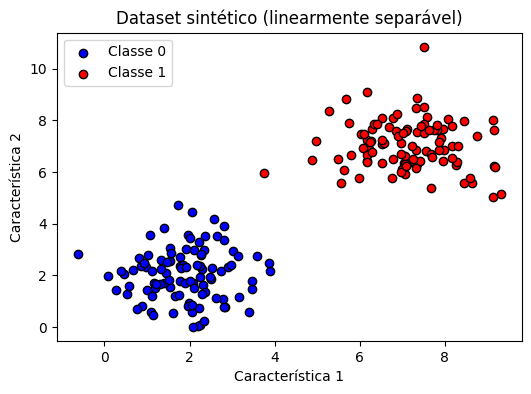

In [ ]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', edgecolors='k')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Dataset sintético (linearmente separável)')
plt.legend()
plt.show()

## ✍️ Sua tarefa: implementar o Perceptron

Implemente a classe abaixo **do zero**. Você precisa escrever:

1. **`_step`** — função degrau: retorne `1` se `x >= 0`, senão `0`.
2. **`fit`** — o treinamento:
   - inicialize `self.weights` e `self.bias`;
   - para cada época, percorra todas as amostras;
   - calcule a predição e o erro `erro = y - y_pred`;
   - se houver erro, atualize pesos e bias com a regra do Perceptron.
3. **`predict`** — calcule a saída linear $z = X \cdot w + b$ e aplique a função degrau em cada linha.

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.1, n_epochs=20):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None

    def _step(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for _ in range(self.n_epochs):
            for xi, yi in zip(X, y):
                y_pred = self._step(np.dot(xi, self.weights) + self.bias)
                erro = yi - y_pred
                self.weights += self.learning_rate * erro * xi
                self.bias += self.learning_rate * erro
        return self

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return (z >= 0).astype(int)

## 💡 Checklist de funções úteis

- `np.zeros(...)` para inicializar pesos.
- `np.dot(...)` (ou o operador `@`) para o produto escalar / matriz-vetor.
- `zip(X, y)` para percorrer amostra e rótulo juntos.
- Conversão booleana → inteiro: `(z >= 0).astype(int)`.

Pense nos **formatos**: `X` é `(n_amostras, n_features)`, `self.weights` deve ter `n_features` elementos e `self.bias` é um escalar.

In [ ]:
model = Perceptron(learning_rate=0.1, n_epochs=20)
model.fit(X, y)
y_pred = model.predict(X)
acuracia = (y_pred == y).mean()
print("Acurácia:", acuracia)

Acurácia: 1.0


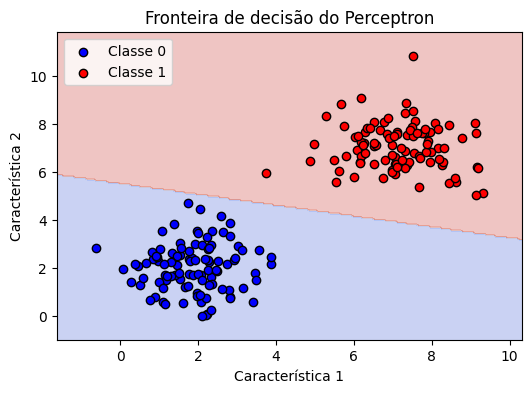

In [ ]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', edgecolors='k')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', edgecolors='k')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.title('Fronteira de decisão do Perceptron')
    plt.legend()
    plt.show()

# Depois de definir `model` na célula anterior, execute:
plot_decision_boundary(model, X, y)

## 📝 Questões — Parte 1

1. O que acontece se os dados **não** forem linearmente separáveis? O algoritmo converge?
2. Qual é o papel do *learning rate*? Teste `0.01`, `0.5` e `1.0` e compare.
3. Por que o Perceptron é considerado um classificador **linear**?
4. Teste o que acontece ao remover o `np.random.seed(42)` e gerar os dados novamente.

**Respostas:**
1. Sim, converge (fica oscilando/não estabiliza se não for linearmente separável).
2. Learning rate controla o tamanho do ajuste; muito baixo aprende devagar, muito alto pode oscilar sem estabilizar.
3. Porque ele separa as classes com uma reta (função linear de x).
4. Sem o seed os dados mudam a cada execução, então o resultado deixa de ser reproduzível.

# Parte 2 (Desafio opcional) — Titanic + Árvore de Decisão 🌲

## 🚢 O dataset Titanic

O objetivo é prever se um passageiro **sobreviveu** (`Survived`) ao naufrágio usando características como classe (`Pclass`), sexo (`Sex`), idade (`Age`), etc.

| Coluna | Descrição |
|---|---|
| `Survived` | 0 = não sobreviveu, 1 = sobreviveu (**alvo**) |
| `Pclass` | Classe da passagem (1, 2, 3) |
| `Sex` | Sexo do passageiro |
| `Age` | Idade |
| `SibSp` | Nº de irmãos/cônjuges a bordo |
| `Parch` | Nº de pais/filhos a bordo |
| `Fare` | Tarifa paga |
| `Embarked` | Porto de embarque (C, Q, S) |

Aqui você vai conduzir a análise do zero: explorar, pré-processar e treinar a **Árvore de Decisão**.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Exploração inicial
titanic.info()
print()
print("Valores ausentes por coluna:")
print(titanic.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Valores ausentes por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embar

## 🔎 Roteiro da análise

Siga as etapas abaixo (cada uma tem uma célula `TODO`):

1. **Análise exploratória** da taxa de sobrevivência.
2. **Pré-processamento**: remover colunas irrelevantes, tratar valores ausentes e codificar categóricas.
3. **Divisão** treino/teste.
4. **Treinamento** da Árvore de Decisão.
5. **Avaliação** (acurácia, matriz de confusão, relatório).
6. **Interpretação** (importância das features e visualização da árvore).

In [ ]:
print(titanic['Survived'].mean())
print(titanic.groupby('Sex')['Survived'].mean())
print(titanic.groupby('Pclass')['Survived'].mean())
print(titanic.groupby('Embarked')['Survived'].mean())

0.3838383838383838
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


## 🧹 Pré-processamento

Lembre-se de:

- **Remover** colunas que não ajudam a prever (`PassengerId`, `Name`, `Ticket`, `Cabin`).
- **Preencher** valores ausentes: mediana para `Age` e `Fare`; moda para `Embarked`.
- **Codificar** `Sex` e `Embarked` em números (ex.: `male` → 0, `female` → 1).

In [ ]:
titanic = titanic.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Fare'] = titanic['Fare'].fillna(titanic['Fare'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})
titanic['Embarked'] = titanic['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})
print(titanic.isna().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [ ]:
X_t = titanic.drop(columns=['Survived'])
y_t = titanic['Survived']
X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.2, random_state=42, stratify=y_t)

## 🌲 Treinando a Árvore de Decisão

Crie e treine um `DecisionTreeClassifier`. Experimente diferentes valores de `max_depth` (ex.: `None`, `3`, `5`, `10`) e observe o efeito na acurácia e no *overfitting*.

In [ ]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_t = tree.predict(X_test)

In [ ]:
print("Acurácia:", accuracy_score(y_test, y_pred_t))
print(confusion_matrix(y_test, y_pred_t))
print(classification_report(y_test, y_pred_t))

Acurácia: 0.7877094972067039
[[104   6]
 [ 32  37]]
              precision    recall  f1-score   support

           0       0.76      0.95      0.85       110
           1       0.86      0.54      0.66        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.75       179
weighted avg       0.80      0.79      0.77       179



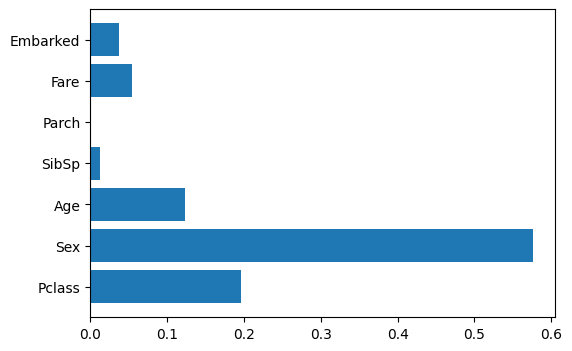

In [ ]:
plt.barh(X_t.columns, tree.feature_importances_)
plt.show()

## 📝 Questões — Parte 2

1. Quais features foram as mais importantes para a árvore? Isso faz sentido historicamente?
2. O que acontece com a acurácia quando você aumenta muito `max_depth`? E o risco de *overfitting*?
3. Como você melhoraria o modelo? (ex.: criar novas features, tratar `Age` de outra forma, usar *random forest*, etc.)
4. Compare a Árvore de Decisão com o Perceptron da Parte 1: quais as diferenças entre um modelo linear e um modelo baseado em árvore?

**Respostas:**
1. Sexo e classe foram as mais importantes; faz sentido, pois mulheres e passageiros de 1ª classe tiveram prioridade nos botes.
2. A acurácia no treino sobe, mas no teste pode cair: a árvore decora os dados (overfitting).
3. Criando novas features, tratando melhor a idade e usando random forest.
4. O Perceptron só separa com uma reta; a árvore cria regras e capta padrões não lineares.

## 🎓 Conclusão

- O **Perceptron** é um modelo linear simples, bom para problemas **linearmente separáveis**.
- A **Árvore de Decisão** aprende regras *não lineares* e é **interpretável**, mas pode sofrer *overfitting*.
- O pré-processamento (valores ausentes e codificação de categóricas) é fundamental antes de treinar qualquer modelo.

Bons estudos! 🚀